In [29]:
import torch
import torch.nn as nn
import torch.optim as optim

import numpy as np
import matplotlib.pyplot as plt

In [30]:
import random

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# (optional but recommended for full reproducibility)-
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [31]:
print("PASS count:", torch.sum(y_train == 1).item())
print("FAIL count:", torch.sum(y_train == 0).item())

PASS count: 336
FAIL count: 372


In [33]:
X_train = np.load("../dataset/X_train.npy")
y_train = np.load("../dataset/y_train.npy")

X_val = np.load("../dataset/X_val.npy")
y_val = np.load("../dataset/y_val.npy")

X_test = np.load("../dataset/X_test.npy")
y_test = np.load("../dataset/y_test.npy")

In [34]:
# Convert to tensor
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
X_val = torch.tensor(X_val, dtype=torch.float32).permute(0, 3, 1, 2)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)

y_train = torch.tensor(y_train, dtype=torch.long)
y_val = torch.tensor(y_val, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [35]:
print("\n=== TRAIN SPLIT ===")
print("PASS:", torch.sum(y_train == 1).item())
print("FAIL:", torch.sum(y_train == 0).item())

print("\n=== VALIDATION SPLIT ===")
print("PASS:", torch.sum(y_val == 1).item())
print("FAIL:", torch.sum(y_val == 0).item())

print("\n=== TEST SPLIT ===")
print("PASS:", torch.sum(y_test == 1).item())
print("FAIL:", torch.sum(y_test == 0).item())


=== TRAIN SPLIT ===
PASS: 336
FAIL: 372

=== VALIDATION SPLIT ===
PASS: 72
FAIL: 80

=== TEST SPLIT ===
PASS: 72
FAIL: 80


In [36]:
class BottleCNN(nn.Module):
    def __init__(self):
        super(BottleCNN, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [37]:
model = BottleCNN()

from torch import tensor

# Class weights: [FAIL, PASS]
weights = tensor([1.0, 1.5])

criterion = nn.CrossEntropyLoss(weight=weights)

optimizer = optim.Adam(model.parameters(), lr=0.0003)

In [38]:
epochs = 10

train_losses = []
val_losses = []

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

for epoch in range(epochs):
    model.train()

    outputs = model(X_train)
    loss = criterion(outputs, y_train)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    train_losses.append(loss.item())

    # DEBUG: predictions
    _, preds = torch.max(outputs, 1)
    print("Sample preds:", preds[:10].cpu().numpy())

    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(X_val)
        val_loss = criterion(val_outputs, y_val)
        val_losses.append(val_loss.item())

    print(f"Epoch {epoch+1}, Train Loss: {loss.item()}, Val Loss: {val_loss.item()}")

X_train shape: torch.Size([708, 3, 224, 224])
y_train shape: torch.Size([708])
Sample preds: [0 0 0 0 0 0 0 0 0 0]
Epoch 1, Train Loss: 0.7037703394889832, Val Loss: 0.6837792992591858
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 2, Train Loss: 0.6819351315498352, Val Loss: 0.6734069585800171
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 3, Train Loss: 0.6705840229988098, Val Loss: 0.6675429344177246
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 4, Train Loss: 0.6655303239822388, Val Loss: 0.662621796131134
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 5, Train Loss: 0.6617296934127808, Val Loss: 0.6527589559555054
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 6, Train Loss: 0.64923095703125, Val Loss: 0.6460674405097961
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 7, Train Loss: 0.6436232924461365, Val Loss: 0.6366199254989624
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 8, Train Loss: 0.6299830079078674, Val Loss: 0.6253454089164734
Sample preds: [1 1 1 1 1 1 1 1 1 1]
Epoch 9, Train Loss: 0.6137862801551819,

In [39]:
epochs = 20  # increased from 10

train_losses = []
val_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    # TRAIN LOOP
    for X_batch, y_batch in train_loader:
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # accumulate properly (important fix)
        total_loss += loss.item() * X_batch.size(0)

    train_loss = total_loss / len(train_loader.dataset)
    train_losses.append(train_loss)

    # VALIDATION LOOP
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    val_loss = val_loss / len(val_loader.dataset)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")

Epoch 1, Train Loss: 0.4876, Val Loss: 0.4023
Epoch 2, Train Loss: 0.3573, Val Loss: 0.3948
Epoch 3, Train Loss: 0.3178, Val Loss: 0.3405
Epoch 4, Train Loss: 0.2947, Val Loss: 0.2726
Epoch 5, Train Loss: 0.2835, Val Loss: 0.2920
Epoch 6, Train Loss: 0.2591, Val Loss: 0.2290
Epoch 7, Train Loss: 0.2104, Val Loss: 0.2224
Epoch 8, Train Loss: 0.1947, Val Loss: 0.2096
Epoch 9, Train Loss: 0.1882, Val Loss: 0.2128
Epoch 10, Train Loss: 0.1717, Val Loss: 0.2077
Epoch 11, Train Loss: 0.1448, Val Loss: 0.2124
Epoch 12, Train Loss: 0.1278, Val Loss: 0.2065
Epoch 13, Train Loss: 0.1685, Val Loss: 0.1870
Epoch 14, Train Loss: 0.1419, Val Loss: 0.1377
Epoch 15, Train Loss: 0.1063, Val Loss: 0.1389
Epoch 16, Train Loss: 0.1020, Val Loss: 0.1264
Epoch 17, Train Loss: 0.1111, Val Loss: 0.1224
Epoch 18, Train Loss: 0.1101, Val Loss: 0.1409
Epoch 19, Train Loss: 0.0841, Val Loss: 0.1368
Epoch 20, Train Loss: 0.0877, Val Loss: 0.1895


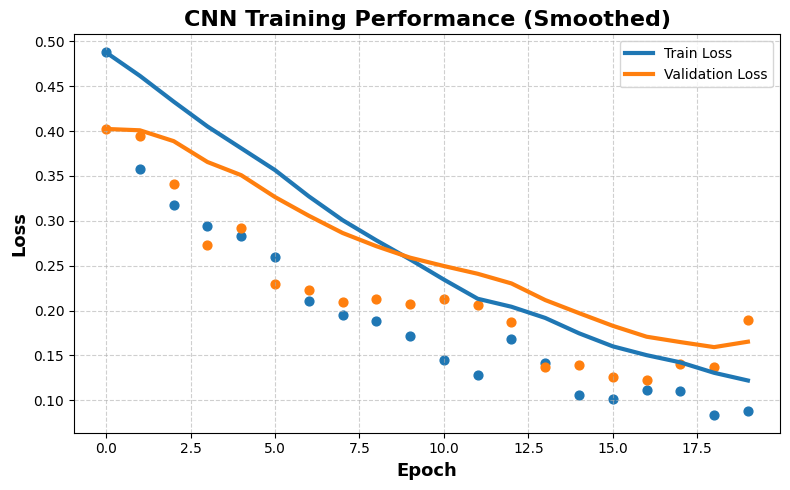

In [40]:
import matplotlib.pyplot as plt

# smoothing function
def smooth(values, alpha=0.8):
    smoothed = []
    for v in values:
        if smoothed:
            smoothed.append(alpha * smoothed[-1] + (1 - alpha) * v)
        else:
            smoothed.append(v)
    return smoothed

plt.figure(figsize=(8,5))

plt.plot(smooth(train_losses), label="Train Loss", linewidth=3)
plt.plot(smooth(val_losses), label="Validation Loss", linewidth=3)

plt.scatter(range(len(train_losses)), train_losses, s=40)
plt.scatter(range(len(val_losses)), val_losses, s=40)

plt.xlabel("Epoch", fontsize=13, fontweight='bold')
plt.ylabel("Loss", fontsize=13, fontweight='bold')
plt.title("CNN Training Performance (Smoothed)", fontsize=16, fontweight='bold')

plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [41]:
model.eval()
with torch.no_grad():
    outputs = model(X_test)
    _, preds = torch.max(outputs, 1)

    accuracy = (preds == y_test).float().mean()

print("CNN Test Accuracy:", accuracy.item())
print("PASS count:", torch.sum(y_train == 1).item())
print("FAIL count:", torch.sum(y_train == 0).item())

CNN Test Accuracy: 0.9144737124443054
PASS count: 336
FAIL count: 372


In [42]:
import os

os.makedirs("../models", exist_ok=True)

torch.save(model.state_dict(), "../models/cnn_model.pth")

print("Model saved successfully!")

Model saved successfully!


## Activation Function Comparison

In [10]:
class BottleCNN_Exp(nn.Module):
    def __init__(self, activation='relu'):
        super(BottleCNN_Exp, self).__init__()

        if activation == 'relu':
            act = nn.ReLU()
        elif activation == 'sigmoid':
            act = nn.Sigmoid()
        elif activation == 'tanh':
            act = nn.Tanh()
        elif activation == 'leakyrelu':
            act = nn.LeakyReLU(0.1)
        else:
            raise ValueError("Unsupported activation")

        self.conv = nn.Sequential(
            nn.Conv2d(3, 16, 3, padding=1),
            act,
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, 3, padding=1),
            act,
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            act,
            nn.MaxPool2d(2)
        )

        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 28 * 28, 128),
            act,
            nn.Dropout(0.5),
            nn.Linear(128, 2)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

In [11]:
def train_model_batch_acc(model, optimizer, epochs=10):
    criterion = nn.CrossEntropyLoss()

    train_losses, val_losses = [], []
    train_accs, val_accs = [], []

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0
        total_loss = 0

        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == y_batch).sum().item()
            total += y_batch.size(0)

        train_losses.append(total_loss / len(train_loader))
        train_accs.append(correct / total)

        # Validation
        model.eval()
        correct, total = 0, 0
        val_loss = 0

        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()

                _, preds = torch.max(outputs, 1)
                correct += (preds == y_batch).sum().item()
                total += y_batch.size(0)

        val_losses.append(val_loss / len(val_loader))
        val_accs.append(correct / total)

        print(f"Epoch {epoch+1}: Train Acc={train_accs[-1]:.3f}, Val Acc={val_accs[-1]:.3f}")

    return train_losses, val_losses, train_accs, val_accs

In [12]:
from torch.utils.data import TensorDataset, DataLoader

# Create datasets
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)

# Create loaders (mini-batch training)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

In [13]:
activations = ['relu', 'sigmoid', 'tanh', 'leakyrelu']
results = {}

for act in activations:
    print(f"\nTraining with {act.upper()}")

    model = BottleCNN_Exp(activation=act)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

    train_loss, val_loss, train_acc, val_acc = train_model_batch_acc(model, optimizer)

    results[act] = {
        "train_loss": train_loss,
        "val_loss": val_loss,
        "train_acc": train_acc,
        "val_acc": val_acc
    }


Training with RELU
Epoch 1: Train Acc=0.676, Val Acc=0.879
Epoch 2: Train Acc=0.882, Val Acc=0.908
Epoch 3: Train Acc=0.920, Val Acc=0.931
Epoch 4: Train Acc=0.945, Val Acc=0.925
Epoch 5: Train Acc=0.953, Val Acc=0.948
Epoch 6: Train Acc=0.953, Val Acc=0.943
Epoch 7: Train Acc=0.974, Val Acc=0.971
Epoch 8: Train Acc=0.985, Val Acc=0.977
Epoch 9: Train Acc=0.979, Val Acc=0.948
Epoch 10: Train Acc=0.991, Val Acc=0.948

Training with SIGMOID
Epoch 1: Train Acc=0.507, Val Acc=0.489
Epoch 2: Train Acc=0.494, Val Acc=0.511
Epoch 3: Train Acc=0.500, Val Acc=0.511
Epoch 4: Train Acc=0.521, Val Acc=0.511
Epoch 5: Train Acc=0.528, Val Acc=0.511
Epoch 6: Train Acc=0.482, Val Acc=0.511
Epoch 7: Train Acc=0.506, Val Acc=0.511
Epoch 8: Train Acc=0.531, Val Acc=0.511
Epoch 9: Train Acc=0.486, Val Acc=0.511
Epoch 10: Train Acc=0.499, Val Acc=0.511

Training with TANH
Epoch 1: Train Acc=0.518, Val Acc=0.534
Epoch 2: Train Acc=0.522, Val Acc=0.511
Epoch 3: Train Acc=0.543, Val Acc=0.511
Epoch 4: Train 

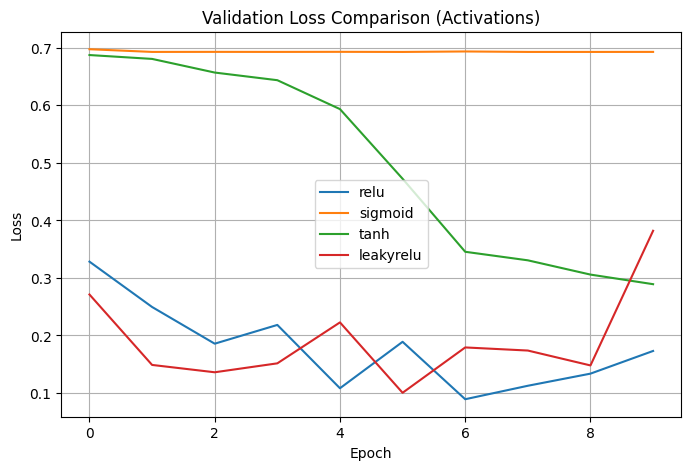

In [14]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(results[act]["val_loss"], label=f"{act}")

plt.title("Validation Loss Comparison (Activations)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

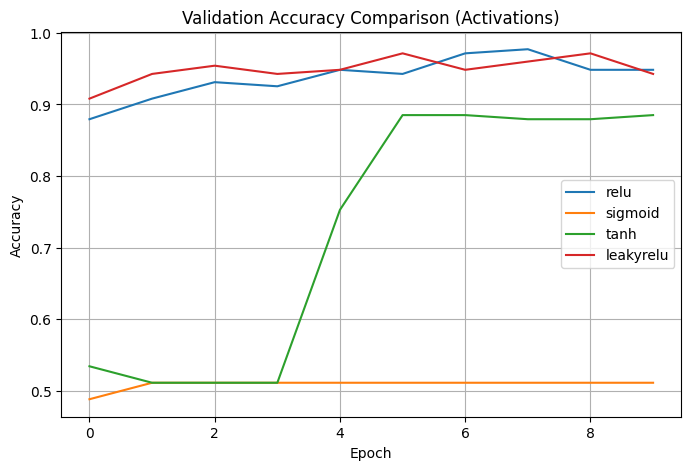

In [15]:
plt.figure(figsize=(8,5))

for act in activations:
    plt.plot(results[act]["val_acc"], label=f"{act}")

plt.title("Validation Accuracy Comparison (Activations)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

In [17]:
best_model = BottleCNN_Exp(activation='relu')
optimizer = torch.optim.Adam(best_model.parameters(), lr=0.001)

train_model_batch_acc(best_model, optimizer)

Epoch 1: Train Acc=0.745, Val Acc=0.879
Epoch 2: Train Acc=0.903, Val Acc=0.897
Epoch 3: Train Acc=0.940, Val Acc=0.868
Epoch 4: Train Acc=0.936, Val Acc=0.931
Epoch 5: Train Acc=0.958, Val Acc=0.960
Epoch 6: Train Acc=0.967, Val Acc=0.960
Epoch 7: Train Acc=0.984, Val Acc=0.966
Epoch 8: Train Acc=0.988, Val Acc=0.966
Epoch 9: Train Acc=0.985, Val Acc=0.948
Epoch 10: Train Acc=0.984, Val Acc=0.960


([0.5033896639943123,
  0.26032091161379445,
  0.16647408311613476,
  0.19477915119093198,
  0.11270074392310701,
  0.08192217869397539,
  0.04202459790170766,
  0.03412809269502759,
  0.04573536154706604,
  0.04578197911793653],
 [0.3092145298918088,
  0.2057968651254972,
  0.4609861026207606,
  0.1593006836871306,
  0.11632415900627772,
  0.07880481580893199,
  0.1041765136954685,
  0.13906488466697434,
  0.17192514644314846,
  0.12118089975168307],
 [0.7450738916256158,
  0.9027093596059114,
  0.9396551724137931,
  0.9359605911330049,
  0.958128078817734,
  0.9667487684729064,
  0.9839901477832512,
  0.9876847290640394,
  0.9852216748768473,
  0.9839901477832512],
 [0.8793103448275862,
  0.896551724137931,
  0.867816091954023,
  0.9310344827586207,
  0.9597701149425287,
  0.9597701149425287,
  0.9655172413793104,
  0.9655172413793104,
  0.9482758620689655,
  0.9597701149425287])

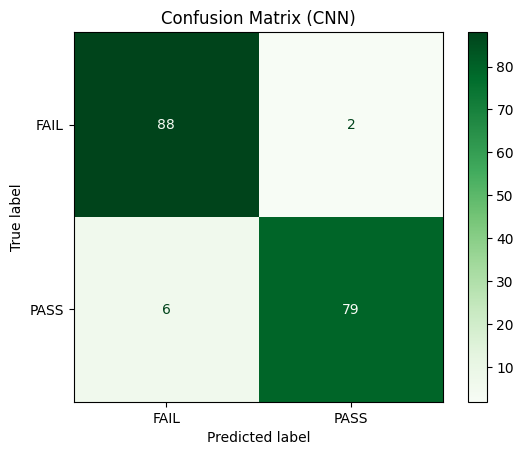

In [18]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_model.eval()
with torch.no_grad():
    outputs = best_model(X_test)
    _, preds = torch.max(outputs, 1)

cm = confusion_matrix(y_test.numpy(), preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAIL", "PASS"])
disp.plot(cmap='Greens')
plt.title("Confusion Matrix (CNN)")
plt.show()

In [19]:
weak_model = BottleCNN_Exp(activation='sigmoid')
optimizer = torch.optim.Adam(weak_model.parameters(), lr=0.001)

train_model_batch_acc(weak_model, optimizer)

Epoch 1: Train Acc=0.505, Val Acc=0.511
Epoch 2: Train Acc=0.501, Val Acc=0.511
Epoch 3: Train Acc=0.522, Val Acc=0.511
Epoch 4: Train Acc=0.502, Val Acc=0.511
Epoch 5: Train Acc=0.510, Val Acc=0.511
Epoch 6: Train Acc=0.498, Val Acc=0.489
Epoch 7: Train Acc=0.483, Val Acc=0.511
Epoch 8: Train Acc=0.480, Val Acc=0.511
Epoch 9: Train Acc=0.493, Val Acc=0.489
Epoch 10: Train Acc=0.511, Val Acc=0.511


([0.9324938563200144,
  0.7155764332184424,
  0.7137553760638604,
  0.7089307674994836,
  0.704993493281878,
  0.7102545499801636,
  0.7077858585577744,
  0.7119010274226849,
  0.7038960044200604,
  0.7004526395064133],
 [0.693000078201294,
  0.6929763456185659,
  0.6930225392182668,
  0.6934230327606201,
  0.6933587193489075,
  0.6933814287185669,
  0.6929351290067037,
  0.6941355566183726,
  0.6935011049111685,
  0.6935087641080221],
 [0.5049261083743842,
  0.5012315270935961,
  0.5221674876847291,
  0.5024630541871922,
  0.5098522167487685,
  0.4975369458128079,
  0.4827586206896552,
  0.4802955665024631,
  0.49261083743842365,
  0.5110837438423645],
 [0.5114942528735632,
  0.5114942528735632,
  0.5114942528735632,
  0.5114942528735632,
  0.5114942528735632,
  0.4885057471264368,
  0.5114942528735632,
  0.5114942528735632,
  0.4885057471264368,
  0.5114942528735632])

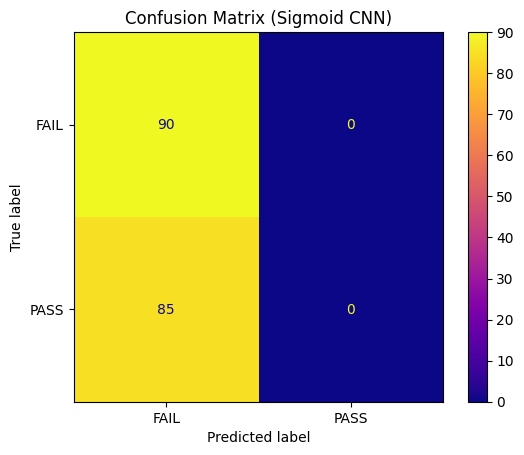

In [20]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

weak_model.eval()
with torch.no_grad():
    outputs = weak_model(X_test)
    _, preds = torch.max(outputs, 1)

cm = confusion_matrix(y_test.numpy(), preds.numpy())

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["FAIL", "PASS"])
disp.plot(cmap='plasma')
plt.title("Confusion Matrix (Sigmoid CNN)")
plt.show()